# Task: Build a Joke Generation Workflow Using LangGraph

## Objective

Create a LangGraph-based workflow that generates, evaluates, improves, and polishes jokes using an LLM.

---
---

## Expected Outcome

The workflow should:

* Generate a joke from a given topic
* Validate whether the joke has a punchline
* Improve weak jokes
* Add a final twist
* Visualize the complete LangGraph execution flow


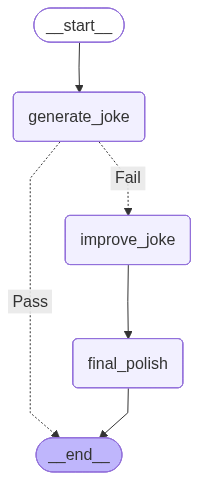

In [8]:
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image

class State(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str


llm = ChatGroq(model='openai/gpt-oss-120b')


# node to generate joke
def generate_joke(state: State):
    """First llm call to generate joke"""
    llm_output = llm.invoke(F"Write a joke about {state['topic']}")
    return {"joke":llm_output.content}

# Gate function to check punchline on joke
def check_punchline(state:State):
    """ Gate function to check joke has punchline"""

    # A simple check - does the joke has "?" or "!"
    if "?" in state['joke'] or "!" in state['joke']:
        return "Pass"
    return "Fail" 

# node to improve the joke
def improve_joke(state:State):
    """ Second llm call to improve the joke"""
    llm_output = llm.invoke(F"make this joke funnier by adding punchline: {state['joke']}")
    return {"improved_joke":llm_output.content}

# node to final polish
def final_polish(state:State):
    """ Thrid llm call to finally polish the joke"""
    llm_output = llm.invoke(F"Add a surprising twist to this joke:{state[['improved_joke']]}")
    return {"final_joke":llm_output.content}



# Build workflow
work_flow = StateGraph(State)


# add nodes
work_flow.add_node("generate_joke",generate_joke)
work_flow.add_node("improve_joke",improve_joke)
work_flow.add_node("final_polish",final_polish)



# Add edges to connect nodes

work_flow.add_edge(START,'generate_joke')
work_flow.add_conditional_edges(
    'generate_joke',check_punchline,{"Fail":'improve_joke',"Pass":END}
)
work_flow.add_edge("improve_joke",'final_polish')
work_flow.add_edge('final_polish',END)



# Compile the graph
chain = work_flow.compile()

# show work_flow
display(Image(chain.get_graph().draw_mermaid_png()))





In [9]:
# Invoke
state = chain.invoke({"topic":"cats"})

print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
Why did the cat sit on the computer?  

Because it wanted to keep an eye on the mouse while staying paws‑itive about its “purr‑formance”!

--- --- ---

Final joke:
Why did the cat sit on the computer?  

Because it wanted to keep an eye on the mouse while staying paws‑itive about its “purr‑formance”!
